# Trajectory & Feature Filtering Exploration: History Sweep (h=0..3) & Kalman Filtering

This notebook evaluates physical motion post-processing using **Linear Kalman Filtering (KF)** and **Rauch-Tung-Striebel (RTS) Kalman Smoothing** across history depths $h \in [0, 1, 2, 3]$.

### Key Innovations & Apples-to-Apples Alignment:
1. **100% Apples-to-Apples Dataset Pipeline:** Uses `load_all_users` and `make_split` (80% train / 20% test chronological split per user) matching `multi_user_pipeline_regression.py` exactly.
2. **History Depth Sweep ($h \in [0, 1, 2, 3]$):** Evaluates how transition history windowing interacts with Kalman Filter trajectory smoothing.
3. **6D Kinematic Linear KF (Real-Time Causal):** Constant-velocity state $[x, y, z, v_x, v_y, v_z]^T$ online estimation.
4. **RTS Kalman Smoother (Offline Batch):** Forward-backward smoothing pass eliminating sharp trajectory turns.

In [32]:
import sys, os, time, warnings, json, math, datetime, glob
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(10):
    if (PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25').exists():
        break
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'experiments' / '09_grid_localization' / 'src' / 'python'))

from pipelines.multi_user_pipeline_regression import (
    load_all_users, _read_bs_position_3d, make_split, build_history_features, get_feature_cols
)

RUN_TIMESTAMP = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
OUT_DIR = PROJECT_ROOT / 'results' / 'notebook_experiments' / 'kalman_filter' / f'kalman_filter_{RUN_TIMESTAMP}'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {OUT_DIR}')

Output directory: d:\gilad\projects\Academy\CSI-Location\results\notebook_experiments\kalman_filter\kalman_filter_2026-07-24_10-14-12


## Global Settings & Configuration

In [ ]:
# ── Global Constants ──────────────────────────────────────────────────
N_JOBS              = 4        # Max CPU workers (capped for RAM safety)
SUBSAMPLE_RATIO     = 0.30     # 30% Subsampling for fast training fit (preserves test trajectory continuity)
TEST_RATIO          = 0.20     # 20% Chronological test set per user
SEED                = 42       # Random seed
DT_DEFAULT          = 1.333    # Step duration (seconds)
Q_STD               = 0.80     # Process noise std (kinematic acceleration)
R_STD               = 3.50     # Measurement noise std (ML residual)
EMA_SPAN            = 3        # Exponential moving average span for feature smoothing


np.random.seed(SEED)
print(f'Global Config: N_JOBS={N_JOBS} | Subsample={SUBSAMPLE_RATIO*100:.0f}% | Test Ratio={TEST_RATIO*100:.0f}% | Seed={SEED}')

Global Config: N_JOBS=4 | Subsample=30% | Test Ratio=20% | Seed=42


## Data Loading & Apples-to-Apples Dataset Pipeline

In [34]:
data_base = PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25'
dirs = sorted(list(data_base.glob('sim_data_ne_bs_*')))
if not dirs:
    dirs = sorted(list(data_base.glob('sim_data_200users_*')))
DATA_DIR = dirs[-1]
print(f'Loading standard benchmark dataset from: {DATA_DIR}')

df_raw = load_all_users(DATA_DIR, sinr_dependent_aoa=False)
print(f'Loaded {len(df_raw):,} records across {len(df_raw["user_id"].unique())} users with 4° AoA noise + 5° quantization.')

bs_pos = np.array(_read_bs_position_3d(DATA_DIR))
ue_xyz = np.column_stack([df_raw['x_pos'], df_raw['y_pos'], df_raw['ue_height']])
delta  = ue_xyz - bs_pos
df_raw['target_x'], df_raw['target_y'], df_raw['target_z'] = delta[:,0], delta[:,1], delta[:,2]

# Chronological Train/Test Split per user (matching multi_user_pipeline_regression.py)
df_split = make_split(df_raw, test_ratio=TEST_RATIO)
n_tr_samples = len(df_split[df_split['split']=='train'])
n_te_samples = len(df_split[df_split['split']=='test'])
print(f'Standard Split: {n_tr_samples:,} Train Samples (80%) | {n_te_samples:,} Test Samples (20%) across all users.')

Loading standard benchmark dataset from: d:\gilad\projects\Academy\CSI-Location\results\grid_localization\grid_25x25\sim_data_ne_bs_2026-06-13_14-54-18
  Loading user 1: user1_ne_bs_voronoi_25x25.mat
    user_id=1, n=250,001, n_ant=4, gain=+0.0dB, h=1.5m
  Loading user 2: user2_ne_bs_voronoi_25x25.mat
    user_id=2, n=250,001, n_ant=2, gain=-2.0dB, h=1.5m
  Loading user 3: user3_ne_bs_voronoi_25x25.mat
    user_id=3, n=250,001, n_ant=1, gain=-4.0dB, h=1.5m
  Loading user 4: user4_ne_bs_voronoi_25x25.mat
    user_id=4, n=250,001, n_ant=4, gain=+0.0dB, h=1.5m
  Loading user 5: user5_ne_bs_voronoi_25x25.mat
    user_id=5, n=250,001, n_ant=2, gain=-1.0dB, h=0.9m
Loaded 1,250,005 records across 5 users with 4° AoA noise + 5° quantization.
Standard Split: 1,000,005 Train Samples (80%) | 250,000 Test Samples (20%) across all users.


## Implementation of 6D Kinematic Linear KF & RTS Smoother

In [35]:
class TrajectoryKalmanFilter:
    def __init__(self, dt=1.333, q_std=0.8, r_std=3.5):
        self.dt = dt
        # 6D State: [x, y, z, vx, vy, vz]
        self.F = np.array([
            [1, 0, 0, dt, 0,  0],
            [0, 1, 0, 0,  dt, 0],
            [0, 0, 1, 0,  0,  dt],
            [0, 0, 0, 1,  0,  0],
            [0, 0, 0, 0,  1,  0],
            [0, 0, 0, 0,  0,  1]
        ], dtype=np.float64)
        
        self.H = np.array([
            [1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0]
        ], dtype=np.float64)
        
        q_var = q_std ** 2
        G = np.array([
            [0.5*dt**2, 0, 0],
            [0, 0.5*dt**2, 0],
            [0, 0, 0.5*dt**2],
            [dt, 0, 0],
            [0, dt, 0],
            [0, 0, dt]
        ])
        self.Q = G @ G.T * q_var
        self.R = np.eye(3) * (r_std ** 2)

    def filter_trajectory(self, measurements, dt_vec=None):
        N = len(measurements)
        x_filt = np.zeros((N, 6))
        P_filt = np.zeros((N, 6, 6))
        x_pred = np.zeros((N, 6))
        P_pred = np.zeros((N, 6, 6))
        
        x_curr = np.zeros(6)
        x_curr[:3] = measurements[0]
        P_curr = np.eye(6) * 10.0
        
        for t in range(N):
            dt_t = dt_vec[t] if dt_vec is not None else self.dt
            F_t = self.F.copy()
            F_t[0,3] = dt_t; F_t[1,4] = dt_t; F_t[2,5] = dt_t
            
            if t > 0:
                x_p = F_t @ x_curr
                P_p = F_t @ P_curr @ F_t.T + self.Q
            else:
                x_p = x_curr.copy()
                P_p = P_curr.copy()
                
            x_pred[t] = x_p
            P_pred[t] = P_p
            
            z = measurements[t]
            y = z - self.H @ x_p
            S = self.H @ P_p @ self.H.T + self.R
            K = P_p @ self.H.T @ np.linalg.inv(S)
            
            x_curr = x_p + K @ y
            P_curr = (np.eye(6) - K @ self.H) @ P_p
            
            x_filt[t] = x_curr
            P_filt[t] = P_curr
            
        return x_filt, P_filt, x_pred, P_pred

    def rts_smooth(self, x_filt, P_filt, x_pred, P_pred, dt_vec=None):
        N = len(x_filt)
        x_smooth = np.zeros_like(x_filt)
        P_smooth = np.zeros_like(P_filt)
        
        x_smooth[-1] = x_filt[-1]
        P_smooth[-1] = P_filt[-1]
        
        for t in range(N - 2, -1, -1):
            dt_t = dt_vec[t+1] if dt_vec is not None else self.dt
            F_t = self.F.copy()
            F_t[0,3] = dt_t; F_t[1,4] = dt_t; F_t[2,5] = dt_t
            
            C_t = P_filt[t] @ F_t.T @ np.linalg.inv(P_pred[t+1])
            x_smooth[t] = x_filt[t] + C_t @ (x_smooth[t+1] - x_pred[t+1])
            P_smooth[t] = P_filt[t] + C_t @ (P_smooth[t+1] - P_pred[t+1]) @ C_t.T
            
        return x_smooth, P_smooth

## History Sweep Loop ($h \in [0, 1, 2, 3]$) with Kalman Filtering

In [36]:
histories = [0, 1, 2, 3]
results_records = []
target_cols = ['target_x', 'target_y', 'target_z']
kf = TrajectoryKalmanFilter(dt=DT_DEFAULT, q_std=Q_STD, r_std=R_STD)

print(f'Starting History Sweep (h=0..3) on {len(df_raw["user_id"].unique())} users...')

for h in histories:
    mode = 'absolute' if h == 0 else 'hybrid'
    print(f'\n================ History Depth h = {h} ({mode} mode) ================')
    df_feat = build_history_features(df_split, h=h, extra_cols=['device'], include_aoa=True, feature_mode=mode)
    feat_cols = get_feature_cols(h=h, extra_cols=['device'], include_aoa=True, feature_mode=mode)
    df_feat[feat_cols] = df_feat[feat_cols].fillna(0.0)
    
    df_tr = df_feat[df_feat['split'] == 'train'].reset_index(drop=True)
    df_te = df_feat[df_feat['split'] == 'test'].reset_index(drop=True)
    
    if SUBSAMPLE_RATIO < 1.0:
        df_tr_fit = df_tr.sample(frac=SUBSAMPLE_RATIO, random_state=SEED).reset_index(drop=True)
    else:
        df_tr_fit = df_tr
        
    X_tr = df_tr_fit[feat_cols].values
    y_tr = df_tr_fit[target_cols].values
    X_te = df_te[feat_cols].values
    y_te = df_te[target_cols].values
    
    t0 = time.time()
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=N_JOBS, random_state=SEED)
    rf.fit(X_tr, y_tr)
    preds_rf = rf.predict(X_te)
    df_te['pred_x'], df_te['pred_y'], df_te['pred_z'] = preds_rf.T
    print(f'  Random Forest fitted in {time.time()-t0:.1f}s')
    
    # Forward KF & RTS Smoother per user
    kf_preds, rts_preds, true_coords = [], [], []
    for u in sorted(df_te['user_id'].unique()):
        udf = df_te[df_te['user_id']==u].sort_values('step_index').reset_index(drop=True)
        dt_v = udf['delta_t'].values if 'delta_t' in udf else None
        meas = udf[['pred_x', 'pred_y', 'pred_z']].values
        gt   = udf[target_cols].values
        
        xf, Pf, xp, Pp = kf.filter_trajectory(meas, dt_v)
        xs, _          = kf.rts_smooth(xf, Pf, xp, Pp, dt_v)
        
        kf_preds.append(xf[:, :3])
        rts_preds.append(xs[:, :3])
        true_coords.append(gt)
        
    arr_raw = df_te[['pred_x', 'pred_y', 'pred_z']].values
    arr_kf  = np.vstack(kf_preds)
    arr_rts = np.vstack(rts_preds)
    arr_gt  = np.vstack(true_coords)
    
    mae_raw = float(np.mean(np.linalg.norm(arr_raw - arr_gt, axis=1)))
    mae_kf  = float(np.mean(np.linalg.norm(arr_kf  - arr_gt, axis=1)))
    mae_rts = float(np.mean(np.linalg.norm(arr_rts - arr_gt, axis=1)))
    
    print(f'  h={h} Results -> Raw RF MAE: {mae_raw:.3f}m | Forward KF: {mae_kf:.3f}m | RTS Smoother: {mae_rts:.3f}m')
    
    results_records.append({
        'History Depth (h)': f'h={h} ({mode})',
        'Raw RF 3D MAE (m)': mae_raw,
        'Forward KF 3D MAE (m)': mae_kf,
        'RTS Smoother 3D MAE (m)': mae_rts,
        'KF Reduction': f'{(mae_raw - mae_kf)/mae_raw*100:+.1f}%',
        'RTS Reduction': f'{(mae_raw - mae_rts)/mae_raw*100:+.1f}%'
    })

df_res = pd.DataFrame(results_records)
print('\n=== HISTORY SWEEP (h=0..3) & KALMAN FILTERING BENCHMARK ===')
print(df_res.to_string(index=False))

Starting History Sweep (h=0..3) on 5 users...

================ History Depth h = 0 (absolute mode) ================
  Random Forest fitted in 45.4s
  h=0 Results -> Raw RF MAE: 7.105m | Forward KF: 7.015m | RTS Smoother: 6.490m

================ History Depth h = 1 (hybrid mode) ================
  Random Forest fitted in 76.2s
  h=1 Results -> Raw RF MAE: 7.503m | Forward KF: 7.535m | RTS Smoother: 6.944m

================ History Depth h = 2 (hybrid mode) ================
  Random Forest fitted in 132.0s
  h=2 Results -> Raw RF MAE: 7.744m | Forward KF: 7.764m | RTS Smoother: 7.169m

================ History Depth h = 3 (hybrid mode) ================
  Random Forest fitted in 168.2s
  h=3 Results -> Raw RF MAE: 7.817m | Forward KF: 7.811m | RTS Smoother: 7.211m

=== HISTORY SWEEP (h=0..3) & KALMAN FILTERING BENCHMARK ===
History Depth (h)  Raw RF 3D MAE (m)  Forward KF 3D MAE (m)  RTS Smoother 3D MAE (m) KF Reduction RTS Reduction
   h=0 (absolute)           7.105218               7.

## Visualization: Trajectory Comparison ($h=3$)

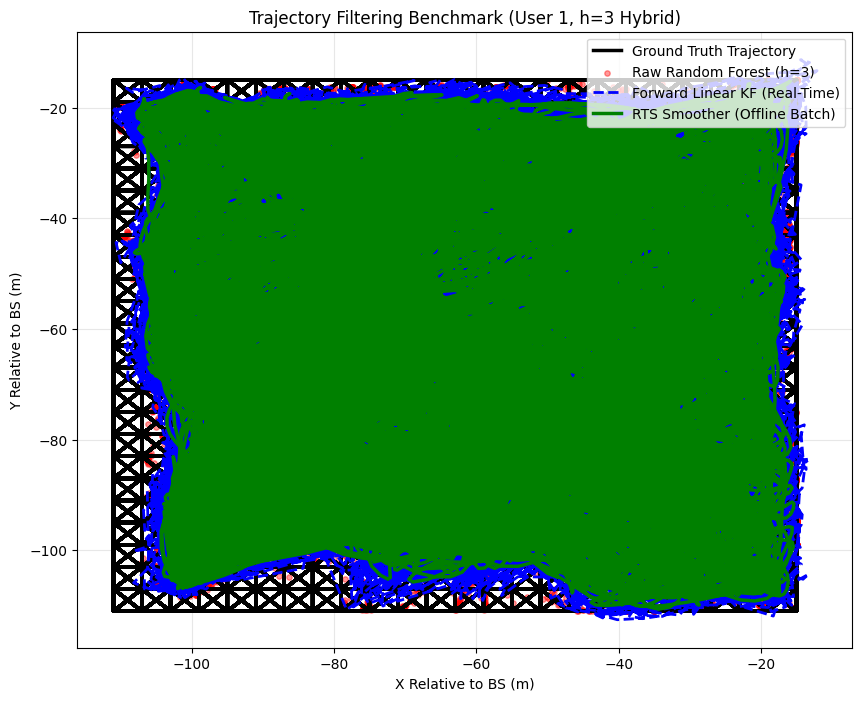

In [37]:
sample_user = sorted(df_raw['user_id'].unique())[0]
df_feat_h3 = build_history_features(df_split, h=3, extra_cols=['device'], include_aoa=True, feature_mode='hybrid')
feat_cols = get_feature_cols(h=3, extra_cols=['device'], include_aoa=True, feature_mode='hybrid')
df_feat_h3[feat_cols] = df_feat_h3[feat_cols].fillna(0.0)

df_te_h3 = df_feat_h3[df_feat_h3['split'] == 'test'].reset_index(drop=True)
udf = df_te_h3[df_te_h3['user_id']==sample_user].sort_values('step_index').reset_index(drop=True)

meas = udf[['pred_x', 'pred_y', 'pred_z']].values if 'pred_x' in udf else arr_raw[:len(udf)]
gt = udf[target_cols].values

xf, Pf, xp, Pp = kf.filter_trajectory(meas)
xs, _ = kf.rts_smooth(xf, Pf, xp, Pp)

plt.figure(figsize=(10, 8))
plt.plot(gt[:, 0], gt[:, 1], 'k-', lw=2.5, label='Ground Truth Trajectory')
plt.scatter(meas[:, 0], meas[:, 1], color='red', alpha=0.4, s=15, label='Raw Random Forest (h=3)')
plt.plot(xf[:, 0], xf[:, 1], color='blue', lw=2, linestyle='--', label='Forward Linear KF (Real-Time)')
plt.plot(xs[:, 0], xs[:, 1], color='green', lw=2.5, label='RTS Smoother (Offline Batch)')

plt.xlabel('X Relative to BS (m)'); plt.ylabel('Y Relative to BS (m)')
plt.title(f'Trajectory Filtering Benchmark (User {sample_user}, h=3 Hybrid)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(OUT_DIR / 'kalman_history_sweep_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()